# Pokémon TCG — recurrent paper net evaluation

`paper_final` = recurrent V-Trace/PPO OSFP net, 5000 iterations. Source data:
`results/paper_eval.json` (`scripts/run_paper_eval.py`) and
`data/paperosfp/main/train.log`. All win rates are slot-swapped with Wilson 95% CI.

In [1]:
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "results").exists())
E = json.loads((ROOT / "results" / "paper_eval.json").read_text())
M = E["matches"]
print("final:", E["final"])
print("phase5d ref:", E["phase5d"])
print("matches:", len(M))

final: /home/sakano/git/kaggle-pokemon/data/paperosfp/main/paper_final.npz
phase5d ref: /home/sakano/git/kaggle-pokemon/data/jointosfp/run2/jointiter_649.npz
matches: 18


## Training curve — gate win rate vs iteration (vs metal_aggro)

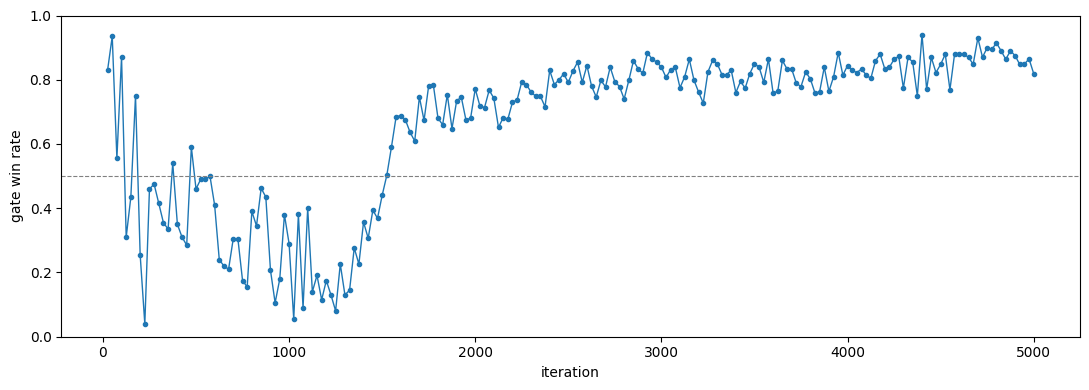

In [2]:
log = (ROOT / "data/paperosfp/main/train.log").read_text().splitlines()
gate = []
for ln in log:
    m = re.search(r"paperiter (\d+).*gate=([0-9.]+)", ln)
    if m:
        gate.append((int(m.group(1)), float(m.group(2))))
gx = [a for a, _ in gate]
gy = [b for _, b in gate]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(gx, gy, marker=".", lw=1)
ax.axhline(0.5, color="gray", ls="--", lw=0.8)
ax.set_xlabel("iteration")
ax.set_ylabel("gate win rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Head-to-head vs baselines

In [3]:
labels = [
    ("vs_phase5d", "vs Phase-5d (full: own deck + play)"),
    ("vs_greedy_samedeck", "vs greedy (shared deck: play only)"),
    ("vs_random_samedeck", "vs random (shared deck: play only)"),
]
rows = [
    [lbl, round(M[k]["winrate"], 3),
     f"[{M[k]['ci_lo']:.3f}, {M[k]['ci_hi']:.3f}]", M[k]["decisive"],
     round(M[k]["avg_turns"], 1), round(M[k]["avg_move_ms"], 3)]
    for k, lbl in labels if k in M
]
pd.DataFrame(
    rows,
    columns=["matchup", "winrate", "95% CI", "decisive", "avg turns", "avg move ms"],
)

,matchup,winrate,95% CI,decisive,avg turns,avg move ms
0,vs Phase-5d (full: own deck + play),0.960,"[0.931, 0.977]",300,30.8,0.542
1,vs greedy (shared deck: play only),0.325,"[0.264, 0.393]",200,13.8,0.256
2,vs random (shared deck: play only),0.835,"[0.777, 0.880]",200,23.4,0.251


## Checkpoint progression — win rate vs Phase-5d by iteration

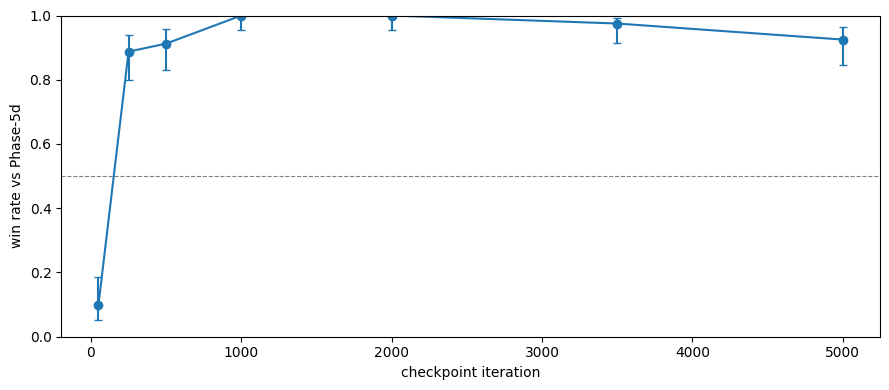

In [4]:
its = [it for it in E["checkpoint_iters"] if f"ckpt_{it}" in M]
ys = np.array([M[f"ckpt_{it}"]["winrate"] for it in its])
lo = np.array([M[f"ckpt_{it}"]["ci_lo"] for it in its])
hi = np.array([M[f"ckpt_{it}"]["ci_hi"] for it in its])
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(
    its, ys, yerr=[np.clip(ys - lo, 0, None), np.clip(hi - ys, 0, None)],
    marker="o", capsize=3,
)
ax.axhline(0.5, color="gray", ls="--", lw=0.8)
ax.set_ylim(0, 1)
ax.set_xlabel("checkpoint iteration")
ax.set_ylabel("win rate vs Phase-5d")
plt.tight_layout()
plt.show()

## Gauntlet — the net's deck vs each meta archetype (greedy-piloted)

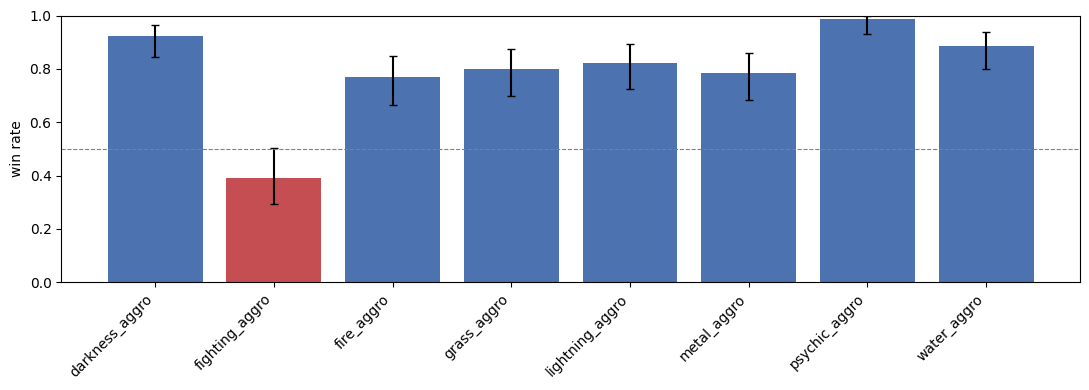

,meta deck,winrate,95% CI,decisive
0,darkness_aggro,0.925,"[0.846, 0.965]",80
1,fighting_aggro,0.392,"[0.292, 0.503]",79
2,fire_aggro,0.769,"[0.664, 0.849]",78
3,grass_aggro,0.800,"[0.700, 0.873]",80
4,lightning_aggro,0.823,"[0.724, 0.891]",79
5,metal_aggro,0.785,"[0.682, 0.861]",79
6,psychic_aggro,0.988,"[0.933, 0.998]",80
7,water_aggro,0.887,"[0.800, 0.940]",80


In [5]:
g = sorted((k.replace("gauntlet_", ""), M[k]) for k in M if k.startswith("gauntlet_"))
names = [n for n, _ in g]
wr = np.array([s["winrate"] for _, s in g])
lo = np.array([s["ci_lo"] for _, s in g])
hi = np.array([s["ci_hi"] for _, s in g])
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(names, wr, color=["#4c72b0" if w >= 0.5 else "#c44e52" for w in wr])
ax.errorbar(
    names, wr, yerr=[np.clip(wr - lo, 0, None), np.clip(hi - wr, 0, None)],
    fmt="none", ecolor="black", capsize=3,
)
ax.axhline(0.5, color="gray", ls="--", lw=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel("win rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
pd.DataFrame(
    [(n, round(s["winrate"], 3), f"[{s['ci_lo']:.3f}, {s['ci_hi']:.3f}]", s["decisive"])
     for n, s in g],
    columns=["meta deck", "winrate", "95% CI", "decisive"],
)

## Deck composition (greedy build) + top cards

In [6]:
d = E["deck"]
print("type composition:", d["greedy_comp"], " | distinct:", d["greedy_distinct"])
pd.DataFrame(d["greedy_top"], columns=["card id", "copies"])

type composition: {'trainer': 22, 'pokemon': 16, 'energy': 22}  | distinct: 18


,card id,copies
0,6,11
1,24,4
2,1227,4
3,15,4
4,1204,4
5,1199,4
6,14,4
7,1006,4


## Sampled-deck diversity (30 samples)

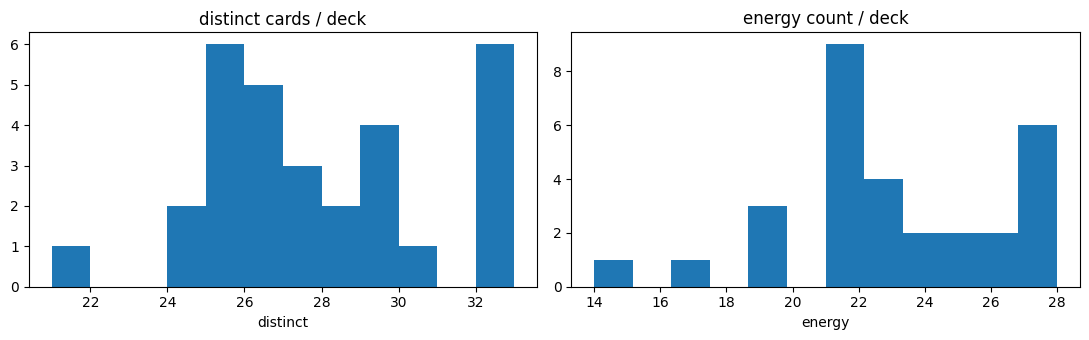

In [7]:
d = E["deck"]
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
axs[0].hist(d["sampled_distinct"], bins=12)
axs[0].set_title("distinct cards / deck")
axs[0].set_xlabel("distinct")
axs[1].hist(d["sampled_energy"], bins=12)
axs[1].set_title("energy count / deck")
axs[1].set_xlabel("energy")
plt.tight_layout()
plt.show()

## Inference cost (per move, recurrent serving)

In [8]:
rows = [
    [k, round(M[k]["avg_move_ms"], 3), round(M[k]["max_move_ms"], 1)]
    for k in ("vs_phase5d", "vs_greedy_samedeck", "vs_random_samedeck") if k in M
]
pd.DataFrame(rows, columns=["match", "avg move ms", "max move ms"])

,match,avg move ms,max move ms
0,vs_phase5d,0.542,68.5
1,vs_greedy_samedeck,0.256,16.6
2,vs_random_samedeck,0.251,23.9
